## Import libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)


## load the dataset

In [2]:
DATA_PATH = "talabat_enhanced_orders.csv"
df = pd.read_csv(DATA_PATH)

df.head(10)


,Order_ID,User_ID,Restaurant_ID,Driver_ID,Item_Name,Quantity,Total_Price,Order_Time,Delivery_Time,Delivery_Duration_Minutes,City,Payment_Method,Order_Status,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability
0,1,U3522,358,485,Fried Chicken,3,273.72,2025-06-16 08:32:00,2025-06-16 09:11:00,39,Alexandria,Wallet,Delivered,Motorbike,31.195082,29.921931,31.191404,29.904982,31.215658,29.910664,1.666106,High,Offline
1,2,U9214,316,65,Sandwich,3,365.82,2025-06-03 21:27:00,2025-06-03 22:00:00,33,Zagazig,Credit Card,Delivered,Motorbike,30.605729,31.503079,30.586047,31.485820,30.580329,31.502380,2.738698,Low,Online
2,3,U7307,357,309,Koshary,3,401.94,2025-06-01 14:48:00,2025-06-01 15:26:00,38,Assiut,Cash,In Transit,Car,27.190180,31.177741,27.164869,31.169218,27.162976,31.189458,2.929079,Medium,Online
3,4,U3612,420,32,Sushi,2,221.18,2025-06-13 02:30:00,2025-06-13 03:22:00,52,Mansoura,Cash,Delivered,Car,31.041846,31.381229,31.035773,31.380440,31.054690,31.401187,0.677498,Low,Online
4,5,U3492,73,364,Koshary,5,355.55,2025-06-06 09:48:00,2025-06-06 10:32:00,44,Mansoura,Wallet,Delivered,Motorbike,31.024141,31.376104,31.026023,31.396881,31.035350,31.389315,1.994769,High,Online
5,6,U7439,750,270,Sushi,3,205.44,2025-06-04 12:16:00,2025-06-04 12:45:00,29,Mansoura,Credit Card,Delivered,Bicycle,31.024140,31.387817,31.029004,31.373869,31.022573,31.380646,1.436807,Medium,Online
6,7,U8948,827,4,Sushi,1,133.94,2025-06-11 04:09:00,2025-06-11 04:49:00,40,Cairo,Wallet,Delivered,Bicycle,30.026723,31.249101,30.043525,31.233372,30.038769,31.231835,2.402167,Low,Online
7,8,U8672,908,109,Shawarma,5,404.80,2025-06-12 18:37:00,2025-06-12 19:18:00,41,Mansoura,Cash,Delivered,Bicycle,31.052547,31.392976,31.053352,31.362834,31.049187,31.373710,2.878434,High,Online
8,9,U2205,814,215,Pizza,1,101.03,2025-06-01 22:18:00,2025-06-01 23:05:00,47,Mansoura,Credit Card,Delivered,Motorbike,31.041945,31.375128,31.041036,31.385503,31.041062,31.368488,0.995562,Low,Online
9,10,U7411,362,416,Pizza,1,130.05,2025-06-09 00:18:00,2025-06-09 01:04:00,46,Cairo,Wallet,Delivered,Bicycle,30.052723,31.236077,30.025107,31.229281,30.062032,31.227642,3.130713,Low,Online


## dataset checking

In [3]:
print("Shape:", df.shape)
print("\nMissing values per column:")
display(df.isna().sum().to_frame("missing_count").T)

print("\nDuplicate rows:", df.duplicated().sum())

Shape: (100000, 23)

Missing values per column:


,Order_ID,User_ID,Restaurant_ID,Driver_ID,Item_Name,Quantity,Total_Price,Order_Time,Delivery_Time,Delivery_Duration_Minutes,City,Payment_Method,Order_Status,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability
missing_count,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0



Duplicate rows: 0


## Target variable and class balance

In [4]:
target_col = "Order_Status"
df[target_col].value_counts()

Order_Status
Delivered     85197
Cancelled      9812
In Transit     4991
Name: count, dtype: int64

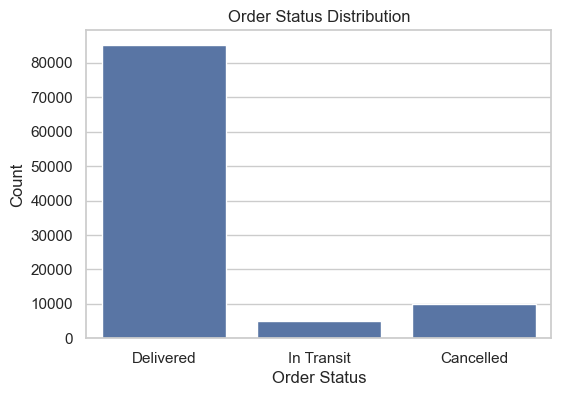

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(x=target_col, data=df)
plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Count")
plt.show()

## Identify feature types

In [6]:
df.dtypes

Order_ID                       int64
User_ID                          str
Restaurant_ID                  int64
Driver_ID                      int64
Item_Name                        str
Quantity                       int64
Total_Price                  float64
Order_Time                       str
Delivery_Time                    str
Delivery_Duration_Minutes      int64
City                             str
Payment_Method                   str
Order_Status                     str
Driver_Vehicle                   str
Restaurant_Lat               float64
Restaurant_Lon               float64
Customer_Lat                 float64
Customer_Lon                 float64
Driver_Lat                   float64
Driver_Lon                   float64
Delivery_Distance_km         float64
Traffic_Level                    str
Driver_Availability              str
dtype: object

## task 2: Try a different rule for `is_peak_hour`

In [7]:
df_fe = df.copy()

# Parse time columns
df_fe["Order_Time"] = pd.to_datetime(df_fe["Order_Time"], errors="coerce")

df_fe["order_hour"] = df_fe["Order_Time"].dt.hour
df_fe["order_dayofweek"] = df_fe["Order_Time"].dt.dayofweek  # Monday=0, Sunday=6
df_fe["is_weekend"] = df_fe["order_dayofweek"].isin([5,6]).astype(int)


# Task 2: Different peak-hour rule
df_fe["is_peak_hour"] = df_fe["order_hour"].isin(list(range(8,11)) + list(range(12,15)) + list(range(18,22))).astype(int)

df_fe[["Order_Time","order_hour","order_dayofweek","is_weekend","is_peak_hour"]].head(10)


,Order_Time,order_hour,order_dayofweek,is_weekend,is_peak_hour
0,2025-06-16 08:32:00,8,0,0,1
1,2025-06-03 21:27:00,21,1,0,1
2,2025-06-01 14:48:00,14,6,1,1
3,2025-06-13 02:30:00,2,4,0,0
4,2025-06-06 09:48:00,9,4,0,1
5,2025-06-04 12:16:00,12,2,0,1
6,2025-06-11 04:09:00,4,2,0,0
7,2025-06-12 18:37:00,18,3,0,1
8,2025-06-01 22:18:00,22,6,1,0
9,2025-06-09 00:18:00,0,0,0,0


In [8]:
df_fe["price_per_item"] = df_fe["Total_Price"] / df_fe["Quantity"]
df_fe[["Quantity","Total_Price","price_per_item"]].head(10)

,Quantity,Total_Price,price_per_item
0,3,273.72,91.24
1,3,365.82,121.94
2,3,401.94,133.98
3,2,221.18,110.59
4,5,355.55,71.11
5,3,205.44,68.48
6,1,133.94,133.94
7,5,404.80,80.96
8,1,101.03,101.03
9,1,130.05,130.05


In [9]:
def haversine_km(lat1, lon1, lat2, lon2):
    """Vectorized Haversine distance in kilometers."""
    R = 6371.0
    lat1 = np.radians(lat1); lon1 = np.radians(lon1)
    lat2 = np.radians(lat2); lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

coord_cols = {"Restaurant_Lat","Restaurant_Lon","Customer_Lat","Customer_Lon"}
if coord_cols.issubset(set(df_fe.columns)):
    df_fe["haversine_rest_to_cust_km"] = haversine_km(
        df_fe["Restaurant_Lat"], df_fe["Restaurant_Lon"],
        df_fe["Customer_Lat"], df_fe["Customer_Lon"]
    )
    display(df_fe[["Delivery_Distance_km","haversine_rest_to_cust_km"]].head(10))
else:
    print("Coordinate columns not found. Skipping Haversine feature.")


,Delivery_Distance_km,haversine_rest_to_cust_km
0,1.666106,1.663239
1,2.738698,2.741931
2,2.929079,2.938058
3,0.677498,0.679441
4,1.994769,1.990872
5,1.436807,1.434924
6,2.402167,2.404753
7,2.878434,2.872665
8,0.995562,0.993613
9,3.130713,3.139677


## Task 1: Create one new engineered feature

In [10]:
# Task 1: New engineered feature

df_fe["distance_ratio"] = df_fe["Delivery_Distance_km"] / (df_fe["haversine_rest_to_cust_km"] + 1e-5)

df_fe[["Delivery_Distance_km","haversine_rest_to_cust_km","distance_ratio"]].head()

,Delivery_Distance_km,haversine_rest_to_cust_km,distance_ratio
0,1.666106,1.663239,1.001718
1,2.738698,2.741931,0.998817
2,2.929079,2.938058,0.996941
3,0.677498,0.679441,0.997125
4,1.994769,1.990872,1.001952


A new feature called distance_ratio was engineered by dividing the reported delivery distance by the Haversine distance between the restaurant and the customer. The Haversine distance represents the straight-line distance, while the delivery distance represents the actual route taken. A higher ratio may indicate longer routes due to road networks, traffic conditions, or detours. This feature may help predict Order_Status, since longer or inefficient routes could increase the probability of delayed or canceled orders.

## Task 3: Change `top_k` in `Item_Name_reduced` (for example 10, 30, 50)

In [11]:
if "Item_Name" in df_fe.columns:
    top_k = 50
    top_items = df_fe["Item_Name"].value_counts().head(top_k).index
    df_fe["Item_Name_reduced"] = np.where(df_fe["Item_Name"].isin(top_items), df_fe["Item_Name"], "Other")
    print("Unique Item_Name:", df_fe["Item_Name"].nunique())
    print("Unique Item_Name_reduced:", df_fe["Item_Name_reduced"].nunique())
    df_fe[["Item_Name","Item_Name_reduced"]].head(10)
else:
    print("Item_Name column not found.")

Unique Item_Name: 9
Unique Item_Name_reduced: 9


## top_k = 10     
accurecy = 0.8519 , top feature importances = (distance_ratio) = 0.067416
## top_k = 30
accurecy = 0.8519 , top feature importances = (distance_ratio) = 0.067416
## top_k = 50
accurecy = 0.8519 , top feature importances = (distance_ratio) = 0.067416

## Discretization

In [12]:
df_fe["price_tier"] = pd.cut(
    df_fe["Total_Price"],
    bins=[0, 100, 250, 500, np.inf],
    labels=["low","medium","high","very_high"]
)

df_fe[["Total_Price","price_tier"]].head(10)


,Total_Price,price_tier
0,273.72,high
1,365.82,high
2,401.94,high
3,221.18,medium
4,355.55,high
5,205.44,medium
6,133.94,medium
7,404.80,high
8,101.03,medium
9,130.05,medium


## Prepare features for modeling

In [13]:
drop_cols = [
    "Order_ID", "User_ID", "Restaurant_ID", "Driver_ID",
    "Order_Time", "Delivery_Time", "Delivery_Duration_Minutes",
    "Item_Name"  
]

# keep only columns that exist (safe for future versions of the dataset)
drop_cols = [c for c in drop_cols if c in df_fe.columns]

X = df_fe.drop(columns=drop_cols + [target_col])
y = df_fe[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)
X.head()


X shape: (100000, 23)
y shape: (100000,)


,Quantity,Total_Price,City,Payment_Method,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability,order_hour,order_dayofweek,is_weekend,is_peak_hour,price_per_item,haversine_rest_to_cust_km,distance_ratio,Item_Name_reduced,price_tier
0,3,273.72,Alexandria,Wallet,Motorbike,31.195082,29.921931,31.191404,29.904982,31.215658,29.910664,1.666106,High,Offline,8,0,0,1,91.24,1.663239,1.001718,Fried Chicken,high
1,3,365.82,Zagazig,Credit Card,Motorbike,30.605729,31.503079,30.586047,31.485820,30.580329,31.502380,2.738698,Low,Online,21,1,0,1,121.94,2.741931,0.998817,Sandwich,high
2,3,401.94,Assiut,Cash,Car,27.190180,31.177741,27.164869,31.169218,27.162976,31.189458,2.929079,Medium,Online,14,6,1,1,133.98,2.938058,0.996941,Koshary,high
3,2,221.18,Mansoura,Cash,Car,31.041846,31.381229,31.035773,31.380440,31.054690,31.401187,0.677498,Low,Online,2,4,0,0,110.59,0.679441,0.997125,Sushi,medium
4,5,355.55,Mansoura,Wallet,Motorbike,31.024141,31.376104,31.026023,31.396881,31.035350,31.389315,1.994769,High,Online,9,4,0,1,71.11,1.990872,1.001952,Koshary,high


## Split into train and test sets

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (80000, 23)
Test size: (20000, 23)


## Encoding and baseline model (Random Forest)

In [ ]:
# Identify categorical and numerical columns automatically
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X_train.select_dtypes(include=[np.number, "bool"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols),
    ]
)

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("rf", rf)
])

model

## Train the model

In [ ]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

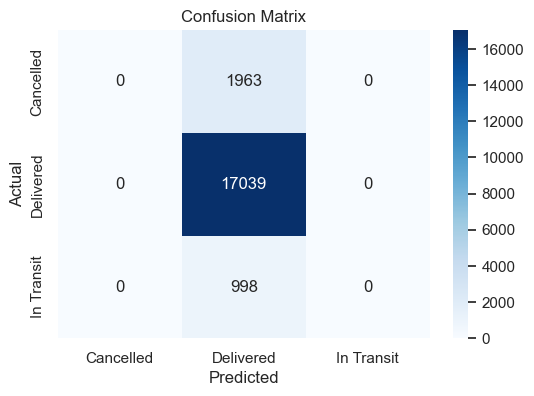

In [23]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## Feature importance

In [18]:
ohe = model.named_steps["preprocess"].named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(categorical_cols) if len(categorical_cols) > 0 else np.array([])
all_feature_names = np.concatenate([cat_feature_names, np.array(numeric_cols)])

importances = model.named_steps["rf"].feature_importances_

fi = (pd.DataFrame({"feature": all_feature_names, "importance": importances})
        .sort_values("importance", ascending=False))

fi.head(15)


,feature,importance
46,distance_ratio,0.067416
44,price_per_item,0.065718
32,Total_Price,0.064815
38,Driver_Lon,0.064591
37,Driver_Lat,0.064382
33,Restaurant_Lat,0.063895
36,Customer_Lon,0.063831
35,Customer_Lat,0.063593
34,Restaurant_Lon,0.063345
39,Delivery_Distance_km,0.062582


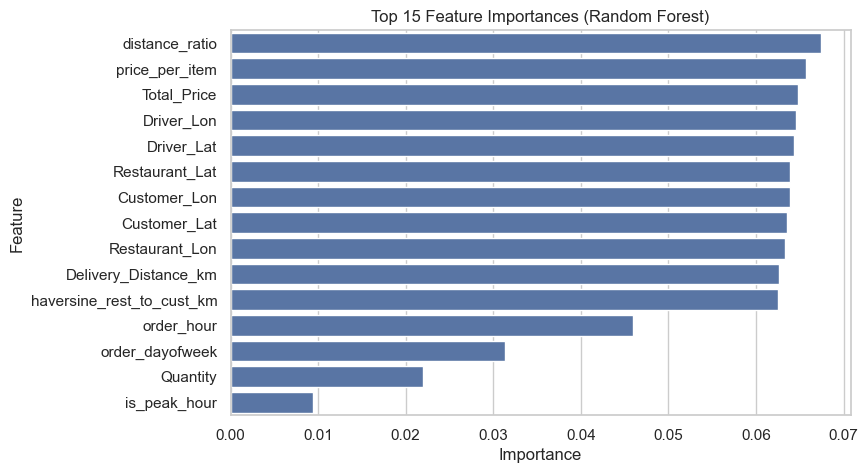

In [19]:
plt.figure(figsize=(8,5))
top_n = 15
sns.barplot(data=fi.head(top_n), x="importance", y="feature")
plt.title(f"Top {top_n} Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


## Task 4: Run the optional feature selection

In [ ]:
from sklearn.feature_selection import SelectFromModel

# Build a new pipeline that selects features based on RF importances
selector = SelectFromModel(
    estimator=RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1, class_weight="balanced_subsample"
    ),
    threshold="median"  # keep features above the median importance
)

model_fs = Pipeline(steps=[
    ("preprocess", preprocess),
    ("select", selector),
    ("rf", RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1, class_weight="balanced_subsample"
    ))
])

model_fs.fit(X_train, y_train)
y_pred_fs = model_fs.predict(X_test)

print("Accuracy (with feature selection):", round(accuracy_score(y_test, y_pred_fs), 4))
print("\nClassification Report (with feature selection):")
print(classification_report(y_test, y_pred_fs))